<h1>CREDIT CARD FRAUD DETECTION PROJECT</h1>

<h1>PHASE 1: SETUP</h1>

<h2>STEP 1.1: IMPORT LIBRARIES</h2>

In [1]:
# ==========================================
# CREDIT CARD FRAUD DETECTION PROJECT
# ==========================================


# ==========================================
# DATA HANDLING LIBRARIES
# ==========================================

# Import pandas for working with tables, datasets, rows, and columns
import pandas as pd

# Import NumPy for numerical calculations and working with arrays
import numpy as np


# ==========================================
# VISUALIZATION LIBRARIES
# ==========================================

# Import Matplotlib for creating charts and graphs
import matplotlib.pyplot as plt

# Import Seaborn for creating simple and attractive statistical charts
import seaborn as sns


# ==========================================
# TRAIN-TEST SPLITTING AND MODEL TUNING
# ==========================================

# Import train_test_split to divide data into training and testing sets
# Import GridSearchCV to find the best combination of model settings
from sklearn.model_selection import train_test_split, GridSearchCV


# ==========================================
# DATA SCALING
# ==========================================

# Import StandardScaler to bring numerical features to a similar scale
# Scaling helps some Machine Learning models perform better
from sklearn.preprocessing import StandardScaler


# ==========================================
# MACHINE LEARNING MODELS
# ==========================================

# Import Logistic Regression for binary classification such as fraud or non-fraud
from sklearn.linear_model import LogisticRegression

# Import Decision Tree classifier for making predictions using decision rules
from sklearn.tree import DecisionTreeClassifier

# Import Random Forest classifier, which combines many decision trees
from sklearn.ensemble import RandomForestClassifier

# Import Support Vector Classifier for classification using Support Vector Machine
from sklearn.svm import SVC


# ==========================================
# MODEL EVALUATION METRICS
# ==========================================

# Import different metrics to check how well the classification models perform
from sklearn.metrics import (
    
    # Shows correct and incorrect predictions in a table
    confusion_matrix,
    
    # Gives precision, recall, F1-score, and other classification results
    classification_report,
    
    # Measures how many predicted fraud cases are actually fraud
    precision_score,
    
    # Measures how many actual fraud cases the model successfully finds
    recall_score,
    
    # Gives a balance between precision and recall
    f1_score,
    
    # Measures how well the model separates fraud and non-fraud cases
    roc_auc_score,
    
    # Gives values needed to draw the ROC curve
    roc_curve,
    
    # Measures the percentage of total predictions that are correct
    accuracy_score
)


# ==========================================
# LIME FOR MODEL EXPLANATION
# ==========================================

# Use try so the program can check whether the LIME library is installed
try:
    
    # Import LIME for explaining individual Machine Learning predictions
    import lime as lime
    
    # Print this message if LIME is imported successfully
    print('Lime imported successfully!')

# Run this block if the LIME library is not installed
except ImportError:
    
    # Tell the user how to install LIME
    print('Lime not installed. Run: pip install lime')
    
    # Keep lime as None if the import fails
    lime = None


# Import the tabular part of LIME for explaining predictions made on table data
import lime.lime_tabular


# ==========================================
# WARNING SETTINGS
# ==========================================

# Import the warnings library to control warning messages
import warnings

# Hide warning messages to keep the Jupyter Notebook output clean
warnings.filterwarnings('ignore')


# Print a message after all required libraries have been imported
print("All libraries imported successfully!")

Lime imported successfully!
All libraries imported successfully!


<h1>PHASE 2: LOAD AND EXPLORE THE DATASET</h1>

<h2>STEP 2.1: LOAD THE DATASET</h2>

In [2]:
# Dataset Name: UCI Credit Card Fraud Detection Dataset
# Download Link: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

# Read the creditcard.csv file and load it into a pandas DataFrame called df
# A DataFrame stores the dataset in rows and columns like a table
df = pd.read_csv("creditcard.csv")

# Print a message to confirm that the dataset was loaded successfully
print("Dataset loaded successfully!")

# Display the shape of the dataset
# .shape shows the number of rows and columns in the dataset
print("Dataset shape:", df.shape)

Dataset loaded successfully!
Dataset shape: (284807, 31)


<h2>STEP 2.2: EXPLORE THE DATASET</h2>

In [3]:
# Display all column names in the dataset
# .columns gets the column names and .tolist() converts them into a normal Python list
print("Columns:", df.columns.tolist())

# Display the first 5 rows of the dataset
# .head() helps us quickly check what the data looks like
print("\nFirst few rows:")
print(df.head())

Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

First few rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.24

<h2>STEP 2.3: UNDERSTAND THE DATASET STRUCTURE </h2>

In [4]:
# Display a summary of the dataset
# .info() shows column names, data types, non-null values, and memory usage
# It helps us quickly understand the structure of the DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

<h2>STEP 2.4: CHECK THE DATA QUALITY</h2>

In [5]:
# Find all columns that are float64
float64_cols = df.select_dtypes(include=['float64']).columns
int64_cols = df.select_dtypes(include=['int64']).columns
# Convert just those columns to float32
df[float64_cols] = df[float64_cols].astype('float32')
# Convert just those columns to int32
df[int64_cols] = df[int64_cols].astype('int32')
# Check if the data type conversion
df.info()

# Check all cells for missing values, count them, and show the total number
# .isnull() finds missing values and .sum().sum() adds all missing values together
print("\nTotal missing values:", df.isnull().sum().sum())

# Display summary statistics for the numerical columns
# .describe() shows values such as count, mean, standard deviation, minimum, maximum, and quartiles
print("\nSummary statistics:\n", df.describe())


<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float32
 1   V1      284807 non-null  float32
 2   V2      284807 non-null  float32
 3   V3      284807 non-null  float32
 4   V4      284807 non-null  float32
 5   V5      284807 non-null  float32
 6   V6      284807 non-null  float32
 7   V7      284807 non-null  float32
 8   V8      284807 non-null  float32
 9   V9      284807 non-null  float32
 10  V10     284807 non-null  float32
 11  V11     284807 non-null  float32
 12  V12     284807 non-null  float32
 13  V13     284807 non-null  float32
 14  V14     284807 non-null  float32
 15  V15     284807 non-null  float32
 16  V16     284807 non-null  float32
 17  V17     284807 non-null  float32
 18  V18     284807 non-null  float32
 19  V19     284807 non-null  float32
 20  V20     284807 non-null  float32
 21  V21     284807 non-nu

<h2>STEP 2.5: CHECK THE SUM OF THE DUPLICATE ROWS</h2>

In [6]:
# Check for duplicate rows and display their total count
# .duplicated() finds repeated rows and .sum() counts how many duplicates are present
print("Duplicate rows:", df.duplicated().sum())

# Display subsequent duplicate rows
duplicate_rows = df[df.duplicated()]
print(duplicate_rows)

# Remove duplicate rows from the dataset and save the cleaned data in a new DataFrame
# .drop_duplicates() keeps only unique rows and removes repeated records
df = df.drop_duplicates()
print("Duplicate rows deleted:", duplicate_rows)

Duplicate rows: 1081
            Time        V1        V2        V3        V4        V5        V6  \
33          26.0 -0.529912  0.873892  1.347247  0.145457  0.414209  0.100223   
35          26.0 -0.535388  0.865268  1.351076  0.147575  0.433680  0.086983   
113         74.0  1.038370  0.127486  0.184456  1.109950  0.441699  0.945283   
114         74.0  1.038370  0.127486  0.184456  1.109950  0.441699  0.945283   
115         74.0  1.038370  0.127486  0.184456  1.109950  0.441699  0.945283   
...          ...       ...       ...       ...       ...       ...       ...   
282987  171288.0  1.912549 -0.455240 -1.750654  0.454324  2.089130  4.160019   
283483  171627.0 -1.464381  1.368119  0.815992 -0.601282 -0.689115 -0.487154   
283485  171627.0 -1.457978  1.378203  0.811515 -0.603760 -0.711883 -0.471672   
284191  172233.0 -2.667936  3.160505 -3.355984  1.007845 -0.377397 -0.109730   
284193  172233.0 -2.691642  3.123168 -3.339407  1.017018 -0.293095 -0.167054   

              V7  

<h2>STEP 2.6: CHECK THE CLASS DISTRIBUTION</h2>

In [7]:
# Count how many transactions belong to each class
# .value_counts() counts the number of times each value appears in the 'Class' column
# In this dataset, Class 0 means normal transaction and Class 1 means fraud
class_counts = df['Class'].value_counts()
# Display the total number of normal and fraud transactions
print("Class Counts:", class_counts)

# Calculate and display the percentage of each class
# normalize=True gives proportions instead of counts
# Multiplying by 100 converts the proportions into percentages
print("\nClass Percentages:", df['Class'].value_counts(normalize=True) * 100)

Class Counts: Class
0    283253
1       473
Name: count, dtype: int64

Class Percentages: Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


<h2>STEP 2.7: CALCULATE IMBALANCE RATIO</h2>

In [8]:
# Count the number of legitimate transactions
# df['Class'] == 0 checks which rows have Class 0, and .sum() counts them
legitimate = (df['Class'] == 0).sum()

# Count the number of fraudulent transactions
# df['Class'] == 1 checks which rows have Class 1, and .sum() counts them
fraud = (df['Class'] == 1).sum()

# Calculate how many legitimate transactions exist for every 1 fraud transaction
ratio = legitimate / fraud

# Display the total number of legitimate transactions
print("Legitimate transactions:", legitimate)

# Display the total number of fraud transactions
print("Fraud transactions:", fraud)

# Display the class imbalance ratio in the form, for example, 577:1
# :.0f rounds the ratio to 0 decimal places
print(f"Imbalance Ratio: {ratio:.0f}:1")

Legitimate transactions: 283253
Fraud transactions: 473
Imbalance Ratio: 599:1


<h2>STEP 2.8: PLOT CLASS DISTRIBUTION</h2>

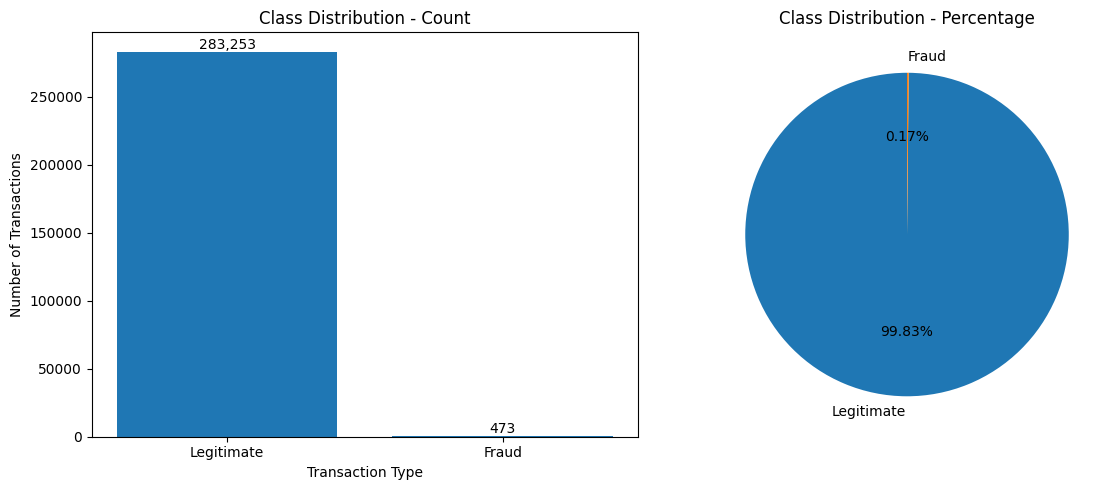

In [9]:
# Visualize Class Imbalance

# Create one figure with 2 charts placed side by side
# 1 means 1 row, 2 means 2 columns, and figsize controls the figure size
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -----------------------------
# 1. Bar Chart
# -----------------------------

# Count how many transactions belong to each class
# .value_counts() counts the number of Class 0 and Class 1 values
class_counts = df['Class'].value_counts()

# Create a bar chart on the first chart area, axes[0]
# The first bar represents legitimate transactions and the second represents fraud
axes[0].bar(
    ['Legitimate', 'Fraud'],
    class_counts.values
)

# Add a title to the bar chart
axes[0].set_title('Class Distribution - Count')

# Add a label to the X-axis
axes[0].set_xlabel('Transaction Type')

# Add a label to the Y-axis
axes[0].set_ylabel('Number of Transactions')

# Add count values above bars
# Loop through each class count
# enumerate() gives both the bar position and its value
for i, value in enumerate(class_counts.values):

    # Write the transaction count above each bar
    axes[0].text(
        i,              # X-position of the text
        value,          # Y-position of the text
        f'{value:,}',   # Show the for each bar with comma
        ha='center',    # Horizontally align the text at the center
        va='bottom'     # Place the text just above the bar
    )

# -----------------------------
# 2. Pie Chart
# -----------------------------

# Create a pie chart on the second chart area, axes[1]
axes[1].pie(
    class_counts.values,                 # Values used to calculate each pie slice
    labels=['Legitimate', 'Fraud'],      # Names shown for each class
    autopct='%1.2f%%',                   # Show percentages with 2 decimal places
    startangle=90                        # Start drawing the pie chart from 90 degrees
)

# Add a title to the pie chart
axes[1].set_title('Class Distribution - Percentage')

# Adjust spacing so the two charts do not overlap
plt.tight_layout()

# Display the final figure
plt.show()

<h2>STEP 2.9: COMPARE TRANSACTION AMOUNTS</h2>

Legitimate Transaction Amounts:
count    283253.000000
mean         88.413582
std         250.379028
min           0.000000
25%           5.670000
50%          22.000000
75%          77.459999
max       25691.160156
Name: Amount, dtype: float64

Fraud Transaction Amounts:
count     473.000000
mean      123.871864
std       260.211060
min         0.000000
25%         1.000000
50%         9.820000
75%       105.889999
max      2125.870117
Name: Amount, dtype: float64


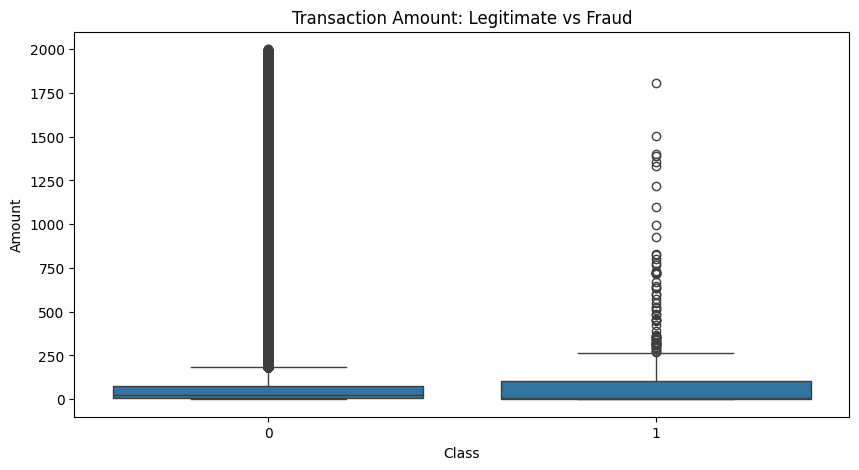

In [10]:
# -----------------------------
# Compare transactions Amounts
# -----------------------------

# Select only legitimate transactions where Class = 0
# Then select the 'Amount' column and show its summary statistics using .describe()
print("Legitimate Transaction Amounts:")
print(df[df['Class'] == 0]['Amount'].describe())


# Select only fraud transactions where Class = 1
# Then select the 'Amount' column and show its summary statistics using .describe()
print("\nFraud Transaction Amounts:")
print(df[df['Class'] == 1]['Amount'].describe())

# Create a new figure for the boxplot
# figsize=(10, 5) sets the width and height of the chart
plt.figure(figsize=(10, 5))

# Create a boxplot to compare transaction amounts for legitimate and fraud transactions
sns.boxplot(
    x='Class',                       # Use the Class column on the X-axis
    y='Amount',                      # Use transaction Amount on the Y-axis
    data=df[df['Amount'] < 2000]     # Use only transactions with Amount below 2000 for clearer visualization
)

# Add a title to explain what the boxplot is comparing
plt.title("Transaction Amount: Legitimate vs Fraud")

# Add a label to the X-axis
# Class 0 represents legitimate transactions and Class 1 represents fraud transactions
plt.xlabel("Class")

# Add a label to the Y-axis to show transaction amount
plt.ylabel("Amount")

# Display the boxplot
plt.show()

<h2>STEP 2.11: CHECK CORRELATION WITH FRAUD</h2>

In [11]:
# Calculate the correlation of every column with the 'Class' column
# .corr() measures how strongly columns are related to each other
# ['Class'] selects only the correlation values related to fraud classification
# .sort_values(ascending=False) sorts from highest positive correlation to lowest
correlation = df.corr()['Class'].sort_values(ascending=False)

# Display the first 10 highest correlation values
# .head(10) returns the first 10 rows
print("Top Features Correlated with Fraud:")
print(correlation.head(10))


# Calculate correlation again using only numeric columns
# numeric_only=True ignores any non-numeric columns if they are present
correlation = df.corr(numeric_only=True)['Class'].sort_values(
    ascending=False    # Sort from highest positive correlation to lowest
)
# Display all correlation values with the 'Class' column
print(correlation)

# Display the 10 features with the highest positive correlation with fraud
print("Top Positive Correlations:")
print(correlation.head(10))

# Display the last 10 values, which contain the strongest negative correlations
# .tail(10) returns the last 10 rows
print("\nStrongest Negative Correlations:")
print(correlation.tail(10))


# Calculate the absolute correlation of each numeric feature with 'Class'
# Absolute correlation ignores the + or - sign and focuses only on correlation strength
absolute_correlation = (
    df.corr(numeric_only=True)['Class']    # Calculate correlation with the Class column
    .abs()                                 # Convert negative values into positive values
    .sort_values(ascending=False)          # Sort from strongest to weakest correlation
)

# Display the 15 features with the strongest overall correlation with fraud
# This includes both strong positive and strong negative relationships
print(absolute_correlation.head(15))

Top Features Correlated with Fraud:
Class    1.000000
V11      0.149067
V4       0.129326
V2       0.084624
V19      0.033631
V8       0.033068
V21      0.026357
V27      0.021892
V20      0.021486
V28      0.009682
Name: Class, dtype: float64
Class     1.000000
V11       0.149067
V4        0.129326
V2        0.084624
V19       0.033631
V8        0.033068
V21       0.026357
V27       0.021892
V20       0.021486
V28       0.009682
Amount    0.005777
V22       0.004887
V26       0.004265
V25       0.003202
V15      -0.003300
V13      -0.003897
V23      -0.006333
V24      -0.007210
Time     -0.012359
V6       -0.043915
V5       -0.087812
V9       -0.094021
V1       -0.094486
V18      -0.105340
V7       -0.172347
V3       -0.182322
V16      -0.187186
V10      -0.206971
V12      -0.250711
V14      -0.293375
V17      -0.313498
Name: Class, dtype: float64
Top Positive Correlations:
Class    1.000000
V11      0.149067
V4       0.129326
V2       0.084624
V19      0.033631
V8       0.033068
V21 

<h1>PHASE 3: DATA PREPROCESSING</h1>

<h2>STEP 3.1: SEPARATE FEATURES (X) AND TARGET (y)</h2>

In [12]:
# Create the feature data (X) by removing the 'Class' column
# axis=1 means we are removing a column, not a row
# X contains the input values that the model will use to make predictions
X = df.drop('Class', axis=1)

# Create the target variable (y) using the 'Class' column
# y contains the correct output: 0 = legitimate transaction and 1 = fraud transaction
y = df['Class']

# Display the shape of the feature dataset
# .shape shows the number of rows and columns in X
print("Features (X) shape:", X.shape)

# Display the shape of the target data
# Since y is a single column, .shape mainly shows the number of rows
print("Target (y) shape:", y.shape)

Features (X) shape: (283726, 30)
Target (y) shape: (283726,)


<h2>STEP 3.2: TRAIN-TEST SPLIT</h2>

In [13]:
# Split the features (X) and target (y) into training and testing datasets
# The training data is used to train the model
# The testing data is used to check how well the trained model performs
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,         # Keep 20% of the data for testing and 80% for training
    random_state=42,       # Gives the same train-test split every time the code runs
    stratify=y             # Keeps the same fraud and legitimate class ratio in both sets
)

# Display the number of rows available for model training
# shape[0] gives the number of rows
print("Training set size:", X_train.shape[0])

# Display the number of rows available for model testing
print("Test set size:", X_test.shape[0])

# Calculate the fraud ratio in the training data
# y_train.sum() counts fraud cases because fraud is represented by 1
# len(y_train) gives the total number of training records
print("Train fraud ratio:", y_train.sum() / len(y_train))

# Calculate the fraud ratio in the testing data
print("Test fraud ratio:", y_test.sum() / len(y_test))

# Calculate and display the fraud percentage in the training data
# .mean() gives the proportion of 1s when the target contains only 0 and 1
# Multiplying by 100 converts the proportion into percentage
print("Training fraud percentage:", y_train.mean() * 100)

# Calculate and display the fraud percentage in the testing data
print("Testing fraud percentage:", y_test.mean() * 100)

Training set size: 226980
Test set size: 56746
Train fraud ratio: 0.0016653449643140364
Test fraud ratio: 0.0016741268107003137
Training fraud percentage: 0.16653449643140364
Testing fraud percentage: 0.16741268107003138


<h2>STEP 3.3: SCALE FEATURES</h2>

In [14]:
# Create a StandardScaler object to scale the feature values
# StandardScaler usually changes features so they have mean near 0 and standard deviation near 1
scaler = StandardScaler()

# Learn the scaling values from the training data and scale it
# .fit_transform() first learns the mean and standard deviation, then transforms the data
# We fit only on training data to avoid using information from the test data
X_train_scaled = scaler.fit_transform(X_train)  # Fit on training

# Scale the test data using the same values learned from the training data
# .transform() only applies the already learned scaling and does not learn again
X_test_scaled = scaler.transform(X_test)        # Transform test

# Verify scaling

# Display the overall mean of the scaled training data
# A value close to 0 shows that the data has been centered properly
print("Scaled training data mean:", X_train_scaled.mean())

# Display the overall standard deviation of the scaled training data
# A value close to 1 shows that the data has been scaled properly
print("Scaled training data std:", X_train_scaled.std())

Scaled training data mean: -2.1579307e-09
Scaled training data std: 1.0


<h2>STEP 3.4: CONVERT TO DATAFRAME</h2>

In [32]:
# Convert the scaled training data from a NumPy array back into a pandas DataFrame
# columns=X.columns keeps the original feature names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)

# Convert the scaled test data from a NumPy array back into a pandas DataFrame
# Using the same column names makes the data easier to read and work with later
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)


<h1>PHASE 4: TRAIN MODELS</h1>

<h2>STEP 4.1: CREATE EVALUATION FUNCTION</h2>

In [16]:
# Create a reusable function to train and evaluate a Machine Learning model
# The function receives the model, training data, testing data, target values, and model name
def evaluate_model(model, X_train, X_test, y_train, y_test, name):

    # Train the model using the training features and correct training labels
    # .fit() helps the model learn patterns from the training data
    model.fit(X_train, y_train)

    # Predict the class for each test record
    # .predict() returns the final class, such as 0 = legitimate and 1 = fraud
    y_pred = model.predict(X_test)

    # Predict the probability of each test record belonging to the fraud class
    # .predict_proba() gives probabilities for both classes
    # [:, 1] selects only the probability of Class 1, which represents fraud
    y_proba = model.predict_proba(X_test)[:, 1]

    # Create the confusion matrix and separate its four values
    # .ravel() converts the 2x2 confusion matrix into four separate values
    tn, fp, fn, tp = confusion_matrix(
        y_test, y_pred
    ).ravel()

    # Calculate precision
    # Precision tells us how many predicted fraud cases were actually fraud
    # zero_division=0 avoids an error if the model predicts no positive cases
    precision = precision_score(y_test, y_pred, zero_division=0)

    # Calculate recall
    # Recall tells us how many actual fraud cases the model successfully detected
    recall = recall_score(y_test, y_pred)

    # Calculate F1-score
    # F1-score gives a balance between precision and recall
    f1 = f1_score(y_test, y_pred)

    # Calculate ROC-AUC using fraud probabilities
    # ROC-AUC measures how well the model separates fraud and legitimate transactions
    roc_auc = roc_auc_score(y_test, y_proba)

    # False Positive Rate
    # Calculate the percentage of legitimate transactions wrongly predicted as fraud
    # fp = false positives and tn = true negatives
    fpr = fp / (fp + tn)

    # Print a separator line to make the output easier to read
    print("=" * 60)

    # Display the name of the model being evaluated
    print(name)

    # Print another separator line
    print("=" * 60)

    # Display the number of legitimate transactions correctly predicted as legitimate
    print(f"True Negatives : {tn}")

    # Display the number of legitimate transactions wrongly predicted as fraud
    print(f"False Positives: {fp}")

    # Display the number of fraud transactions wrongly predicted as legitimate
    print(f"False Negatives: {fn}")

    # Display the number of fraud transactions correctly predicted as fraud
    print(f"True Positives : {tp}")

    # Display precision rounded to 4 decimal places
    # \n adds a blank line before the metric section
    print(f"\nPrecision : {precision:.4f}")

    # Display recall rounded to 4 decimal places
    print(f"Recall    : {recall:.4f}")

    # Display F1-score rounded to 4 decimal places
    print(f"F1-Score  : {f1:.4f}")

    # Display ROC-AUC rounded to 4 decimal places
    print(f"ROC-AUC   : {roc_auc:.4f}")

    # Display False Positive Rate as a percentage with 4 decimal places
    print(f"False Positive Rate: {fpr:.4%}")

    # Return all important model results in a dictionary
    # This allows us to save and compare the results later
    return {

        # Store the model name
        'name': name,

        # Store the trained model
        'model': model,

        # Store the predicted classes
        'predictions': y_pred,

        # Store the predicted fraud probabilities
        'probabilities': y_proba,

        # Store the precision score
        'precision': precision,

        # Store the recall score
        'recall': recall,

        # Store the F1-score
        'f1': f1,

        # Store the ROC-AUC score
        'roc_auc': roc_auc,

        # Store the False Positive Rate
        'false_positive_rate': fpr
    }

<h2>STEP 4.2: MODEL 1 - TRAIN LOGISTIC REGRESSION</h2>

In [17]:
# Create a Logistic Regression model for fraud classification
lr_model = LogisticRegression(
    
    # Give more importance to the minority class (fraud)
    # 'balanced' automatically adjusts class weights based on class frequency
    class_weight='balanced',
    
    # Allow the model up to 1000 training iterations to find a good solution
    max_iter=1000,
    
    # Keep the model results reproducible when randomness is involved
    random_state=42
)

# Train and evaluate the Logistic Regression model using our evaluation function
lr_result = evaluate_model(
    
    # Pass the Logistic Regression model
    lr_model,
    
    # Pass the scaled training features for model training
    X_train_scaled,
    
    # Pass the scaled test features for model evaluation
    X_test_scaled,
    
    # Pass the correct training target values
    y_train,
    
    # Pass the correct test target values
    y_test,
    
    # Give the model a name that will be shown in the evaluation output
    "Logistic Regression"
)

Logistic Regression
True Negatives : 55262
False Positives: 1389
False Negatives: 12
True Positives : 83

Precision : 0.0564
Recall    : 0.8737
F1-Score  : 0.1059
ROC-AUC   : 0.9657
False Positive Rate: 2.4519%


<h2>STEP 4.3: MODEL 2 - TRAIN DECISION TREE</h2>

In [18]:
# Create a Decision Tree model for fraud classification
dt_model = DecisionTreeClassifier(
    
    # Give more importance to the minority class (fraud)
    # 'balanced' automatically adjusts class weights based on class frequency
    class_weight='balanced',
    
    # Limit the tree to a maximum depth of 10 levels
    # This helps reduce overfitting by preventing the tree from becoming too complex
    max_depth=10,
    
    # Give the same result each time when randomness is involved
    random_state=42
)

# Train and evaluate the Decision Tree model using our evaluation function
dt_result = evaluate_model(
    
    # Pass the Decision Tree model
    dt_model,
    
    # Pass the scaled training features for model training
    X_train_scaled,
    
    # Pass the scaled test features for model evaluation
    X_test_scaled,
    
    # Pass the correct training target values
    y_train,
    
    # Pass the correct test target values
    y_test,
    
    # Give the model a name that will be shown in the evaluation output
    "Decision Tree"
)

Decision Tree
True Negatives : 56406
False Positives: 245
False Negatives: 21
True Positives : 74

Precision : 0.2320
Recall    : 0.7789
F1-Score  : 0.3575
ROC-AUC   : 0.8886
False Positive Rate: 0.4325%


<h2>STEP 4.4: MODEL 3 - TRAIN RANDOM FOREST</h2>

In [19]:
# Create a Random Forest model for fraud classification
rf_model = RandomForestClassifier(
    
    # Build 100 decision trees inside the Random Forest
    # More trees can improve stability but may increase training time
    n_estimators=100,
    
    # Give more importance to the minority class (fraud)
    # 'balanced' automatically adjusts class weights based on class frequency
    class_weight='balanced',
    
    # Limit each decision tree to a maximum depth of 15 levels
    # This helps control model complexity and reduce overfitting
    max_depth=15,
    
    # Give the same result each time when randomness is involved
    random_state=42,
    
    # Use all available CPU cores to train the model faster
    # -1 means use all available processors
    n_jobs=-1
)

# Train and evaluate the Random Forest model using our evaluation function
rf_result = evaluate_model(
    
    # Pass the Random Forest model
    rf_model,
    
    # Pass the scaled training features for model training
    X_train_scaled,
    
    # Pass the scaled test features for model evaluation
    X_test_scaled,
    
    # Pass the correct training target values
    y_train,
    
    # Pass the correct test target values
    y_test,
    
    # Give the model a name that will be shown in the evaluation output
    "Random Forest"
)

Random Forest
True Negatives : 56646
False Positives: 5
False Negatives: 26
True Positives : 69

Precision : 0.9324
Recall    : 0.7263
F1-Score  : 0.8166
ROC-AUC   : 0.9424
False Positive Rate: 0.0088%


<h2>STEP 4.5: MODEL 4 - TRAIN SVM</h2>

In [20]:
# Create a Support Vector Machine (SVM) model for fraud classification
svm_model = SVC(
    
    # Use the RBF kernel to handle non-linear patterns in the data
    # RBF helps SVM create a curved decision boundary when needed
    kernel='rbf',
    
    # Enable probability predictions
    # This is needed because our evaluation function uses .predict_proba()
    probability=True,
    
    # Give more importance to the minority class (fraud)
    # 'balanced' automatically adjusts class weights based on class frequency
    class_weight='balanced',
    
    # Give the same result each time when randomness is involved
    random_state=42
)

# Train and evaluate the Support Vector Machine model using our evaluation function
svm_result = evaluate_model(
    
    # Pass the SVM model
    svm_model,
    
    # Pass the scaled training features for model training
    X_train_scaled,
    
    # Pass the scaled test features for model evaluation
    X_test_scaled,
    
    # Pass the correct training target values
    y_train,
    
    # Pass the correct test target values
    y_test,
    
    # Give the model a name that will be shown in the evaluation output
    "Support Vector Machine"
)

Support Vector Machine
True Negatives : 56548
False Positives: 103
False Negatives: 35
True Positives : 60

Precision : 0.3681
Recall    : 0.6316
F1-Score  : 0.4651
ROC-AUC   : 0.9647
False Positive Rate: 0.1818%


<h2>STEP 5.1: CREATE COMPARISON TABLE</h2>

In [21]:
# Store the evaluation results of all models in one list
# This makes it easier to compare the models together
results_list = [
    
    # Logistic Regression evaluation result
    lr_result,
    
    # Decision Tree evaluation result
    dt_result,
    
    # Random Forest evaluation result
    rf_result,
    
    # Support Vector Machine evaluation result
    svm_result
]

# Create a DataFrame containing the important evaluation metrics for each model
# A DataFrame gives us a clean table for model comparison
comparison_df = pd.DataFrame([
    
    {
        # Get the model name from the result dictionary
        'Model': r['name'],
        
        # Get the precision score of the model
        'Precision': r['precision'],
        
        # Get the recall score of the model
        'Recall': r['recall'],
        
        # Get the F1-score of the model
        'F1-Score': r['f1'],
        
        # Get the ROC-AUC score of the model
        'ROC-AUC': r['roc_auc'],
        
        # Get the False Positive Rate of the model
        'False Positive Rate': r['false_positive_rate']
    }
    
    # Loop through every model result stored in results_list
    # r represents one model's result dictionary at a time
    for r in results_list
])

# Sort the model comparison table using F1-Score
# ascending=False places the model with the highest F1-Score at the top
comparison_df.sort_values(
    'F1-Score',
    ascending=False
)

,Model,Precision,Recall,F1-Score,ROC-AUC,False Positive Rate
2,Random Forest,0.932432,0.726316,0.816568,0.942422,0.000088
3,Support Vector Machine,0.368098,0.631579,0.465116,0.964721,0.001818
1,Decision Tree,0.231975,0.778947,0.357488,0.888640,0.004325
0,Logistic Regression,0.056386,0.873684,0.105935,0.965654,0.024519


<h2>STEP 5.2: VISUALIZE CONFUSION MATRICES</h2>

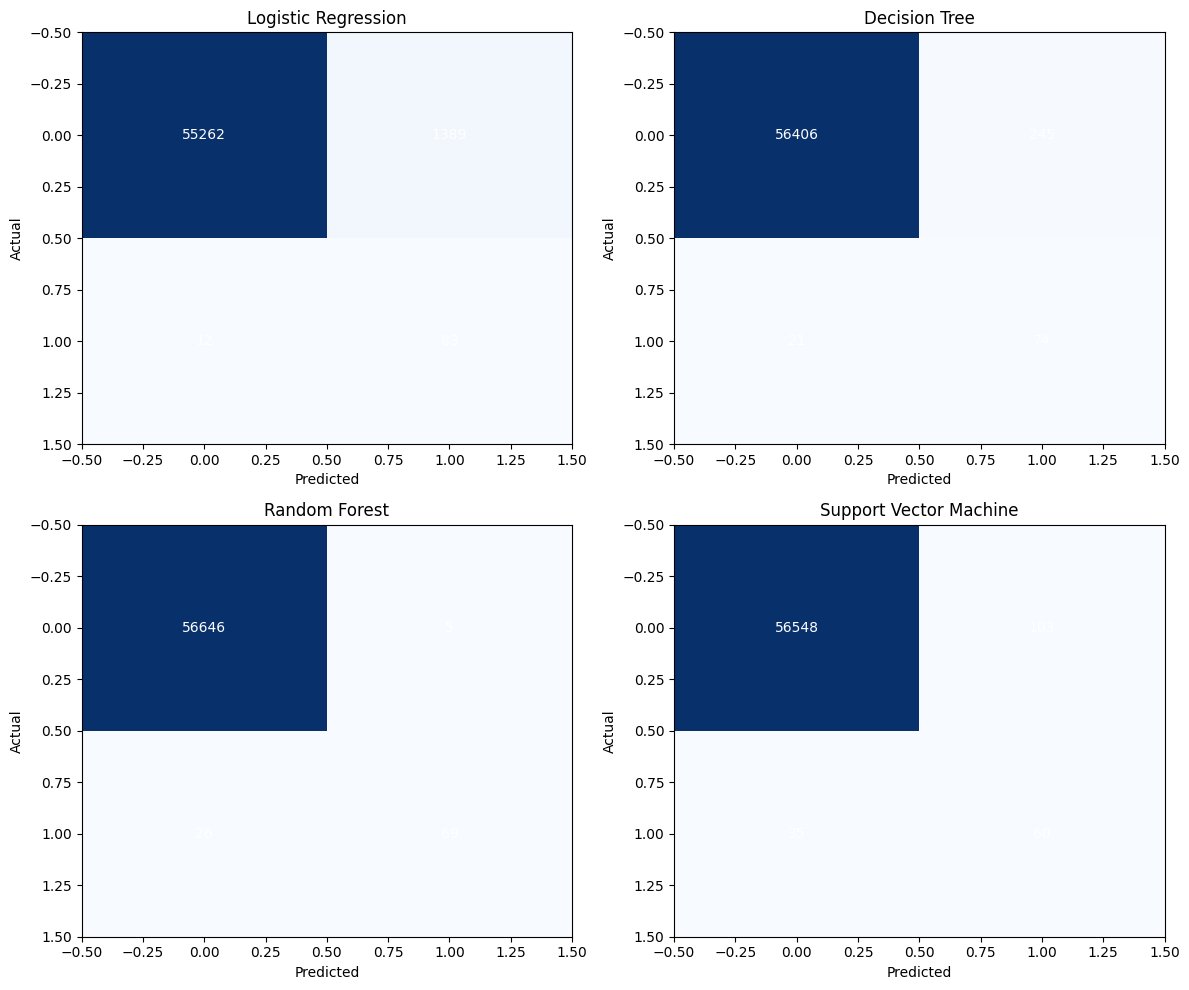

In [22]:
# Create a figure with 4 chart areas arranged in 2 rows and 2 columns
# figsize controls the overall size of the figure
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Convert the 2x2 axes array into a simple one-dimensional list
# This makes it easier to access each chart using axes[idx]
axes = axes.flatten()

# Loop through each model result one by one
# enumerate() gives both the position number (idx) and the model result
for idx, result in enumerate(results_list):

    # Create the confusion matrix for the current model
    # It compares the actual test values with the model's predictions
    cm = confusion_matrix(y_test, result['predictions'])

    # Display the confusion matrix as a colored image
    # cmap='Blues' uses blue shades and aspect='auto' adjusts the chart size automatically
    axes[idx].imshow(cm, cmap='Blues', aspect='auto')

    # Use the model name as the title of the current confusion matrix
    axes[idx].set_title(result['name'])

    # Add a label to the X-axis to represent predicted classes
    axes[idx].set_xlabel('Predicted')

    # Add a label to the Y-axis to represent actual classes
    axes[idx].set_ylabel('Actual')

    # Add text

    # Loop through the 2 rows of the confusion matrix
    for i in range(2):

        # Loop through the 2 columns of the confusion matrix
        for j in range(2):

            # Write the confusion matrix value inside each cell
            # j gives the X-position and i gives the Y-position
            # ha and va center the text inside the cell
            axes[idx].text(
                j,
                i,
                cm[i, j],
                ha='center',
                va='center',
                color='white'
            )

# Adjust spacing so the four charts do not overlap
plt.tight_layout()

# Display all confusion matrices
plt.show()

<h2>STEP 5.3: PLOT ROC CURVES</h2>

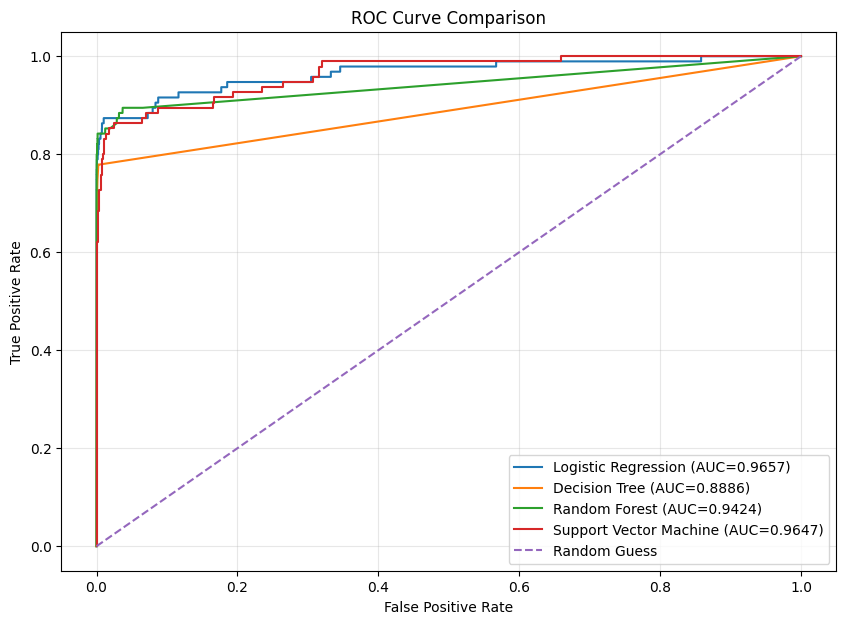

In [23]:
# Create a new figure for comparing ROC curves of all models
# figsize=(10, 7) sets the width and height of the chart
plt.figure(figsize=(10, 7))

# Loop through the result of each trained model
for result in results_list:

    # Calculate the ROC curve values for the current model
    # y_test contains the actual classes
    # result['probabilities'] contains the predicted fraud probabilities
    # roc_curve() returns False Positive Rate, True Positive Rate, and thresholds
    fpr, tpr, thresholds = roc_curve(
        y_test,
        result['probabilities']
    )

    # Plot the ROC curve for the current model
    plt.plot(
        fpr,    # False Positive Rate values are shown on the X-axis
        tpr,    # True Positive Rate (Recall) values are shown on the Y-axis

        # Show the model name and its ROC-AUC score in the legend
        # :.4f displays the ROC-AUC value up to 4 decimal places
        label=f"{result['name']} (AUC={result['roc_auc']:.4f})"
    )

# Draw a diagonal reference line for a model that makes random guesses
# A good model should normally have its ROC curve above this line
plt.plot(
    [0, 1],              # X-axis values from 0 to 1
    [0, 1],              # Y-axis values from 0 to 1
    '--',                # Draw the line using a dashed style
    label='Random Guess' # Name shown in the legend
)

# Add a label to the X-axis
# False Positive Rate shows how often legitimate transactions are wrongly marked as fraud
plt.xlabel("False Positive Rate")

# Add a label to the Y-axis
# True Positive Rate shows how many actual fraud transactions are correctly detected
plt.ylabel("True Positive Rate")

# Add a title to the ROC curve comparison chart
plt.title("ROC Curve Comparison")

# Display the model names and their AUC scores
plt.legend()

# Add light grid lines to make the chart easier to read
# alpha=0.3 makes the grid lines lighter
plt.grid(alpha=0.3)

<h2>STEP 5.4: FIND THE BEST MODEL</h2>

In [24]:
# Find the row of the model with the highest F1-score
# .idxmax() returns the index of the highest value in the 'F1-Score' column
# .loc[] uses that index to select the complete row from the DataFrame
best_row = comparison_df.loc[
    comparison_df['F1-Score'].idxmax()
]

# Display the complete result row of the model with the highest F1-score
print("Best model based on F1-score:")
print(best_row)

Best model based on F1-score:
Model                  Random Forest
Precision                   0.932432
Recall                      0.726316
F1-Score                    0.816568
ROC-AUC                     0.942422
False Positive Rate         0.000088
Name: 2, dtype: object


<h1>PHASE 6: HYPERPARAMETER TUNING</h1>

<h2>STEP 6.1: TUNE RANDOM FOREST (BEST MODEL)</h2>

In [25]:
# Import GridSearchCV for testing different combinations of model settings
# It helps us find the best hyperparameters for the model
from sklearn.model_selection import GridSearchCV

# Create a dictionary containing the Random Forest settings we want to test
param_grid = {

    # Try Random Forest models with 100 and 200 decision trees
    'n_estimators': [100, 200],

    # Try different maximum depths for each decision tree
    # This controls how deep and complex each tree can become
    'max_depth': [10, 15, 20],

    # Minimum number of samples needed to split a node into more branches
    'min_samples_split': [5, 10],

    # Minimum number of samples that must remain in a leaf node
    'min_samples_leaf': [2, 4]
}

# Create the GridSearchCV object to find the best Random Forest settings
grid_search = GridSearchCV(

    # Create the Random Forest model that GridSearchCV will tune
    # class_weight='balanced' gives more importance to the minority fraud class
    # random_state=42 helps produce the same results when randomness is used
    RandomForestClassifier(class_weight='balanced', random_state=42),

    # Pass the dictionary containing all parameter combinations to test
    param_grid,

    # Use 5-fold cross-validation
    # The training data is divided into 5 parts and the model is tested 5 times
    cv=5,

    # Use F1-score to decide which parameter combination performs best
    # F1-score balances precision and recall
    scoring='f1',

    # Use all available CPU cores to make the search faster
    # -1 means use all available processors
    n_jobs=-1,

    # Show progress messages while GridSearchCV is running
    # verbose=1 gives basic progress information
    verbose=1
)

# Print a message before starting the hyperparameter search
print("Starting Grid Search (this takes 5-10 minutes)...")

# Test all parameter combinations using the training data
# .fit() trains many Random Forest models and finds the best combination
grid_search.fit(X_train_scaled, y_train)

# Display the best parameter combination found by GridSearchCV
# best_params_ stores the settings that gave the best cross-validation F1-score
print(f"Best parameters: {grid_search.best_params_}")

# Display the best average F1-score obtained during cross-validation
# :.4f displays the score up to 4 decimal places
print(f"Best F1-Score (CV): {grid_search.best_score_:.4f}")

# Evaluate on test set

# Use the best tuned Random Forest model to predict classes on the test data
# .predict() returns 0 for legitimate and 1 for fraud
y_pred_tuned = grid_search.predict(X_test_scaled)

# Predict the probability that each test transaction belongs to the fraud class
# .predict_proba() gives probabilities for both classes
# [:, 1] selects only the probability of Class 1, which represents fraud
y_proba_tuned = grid_search.predict_proba(X_test_scaled)[:, 1]

# Print a heading before displaying the final test results
# \n adds a blank line before the heading
print(f"\nTest Set Performance:")

# Calculate and display precision on the test data
# Precision shows how many predicted fraud cases were actually fraud
print(f"Precision: {precision_score(y_test, y_pred_tuned):.4f}")

# Calculate and display recall on the test data
# Recall shows how many actual fraud cases were successfully detected
print(f"Recall: {recall_score(y_test, y_pred_tuned):.4f}")

# Calculate and display the F1-score on the test data
# F1-score gives a balance between precision and recall
print(f"F1-Score: {f1_score(y_test, y_pred_tuned):.4f}")

# Calculate and display ROC-AUC using the predicted fraud probabilities
# ROC-AUC shows how well the model separates fraud and legitimate transactions
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_tuned):.4f}")

Starting Grid Search (this takes 5-10 minutes)...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best F1-Score (CV): 0.8517

Test Set Performance:
Precision: 0.9583
Recall: 0.7263
F1-Score: 0.8263
ROC-AUC: 0.9528


<h1>PHASE 7: FEATURE IMPORTANCE</h1>

<h2>STEP 7.1: EXTRACT FEATURE IMPORTANCE</h2>

In [26]:
# Get the best Random Forest model found by GridSearchCV
# best_estimator_ stores the model with the best parameter combination
best_model = grid_search.best_estimator_

# Create a DataFrame to show how important each feature is for the model
feature_importance = pd.DataFrame({

    # Store the original feature names
    'Feature': X.columns,

    # Get the importance score of each feature from the trained Random Forest model
    # Higher importance means the feature had more influence on the model's decisions
    'Importance': best_model.feature_importances_

# Sort the features from highest importance to lowest importance
}).sort_values('Importance', ascending=False)


# Display the 15 features with the highest importance scores
# .head(15) returns the first 15 rows
print("Top 15 Features:")
print(feature_importance.head(15))

Top 15 Features:
   Feature  Importance
14     V14    0.178881
10     V10    0.117150
12     V12    0.108532
4       V4    0.103215
17     V17    0.097075
16     V16    0.058725
3       V3    0.057390
11     V11    0.051234
2       V2    0.030060
7       V7    0.022648
9       V9    0.018435
19     V19    0.014688
21     V21    0.014475
27     V27    0.013974
18     V18    0.011082


<h2>STEP 7.2: VISUALIZE FEATURE IMPORTANCE</h2>

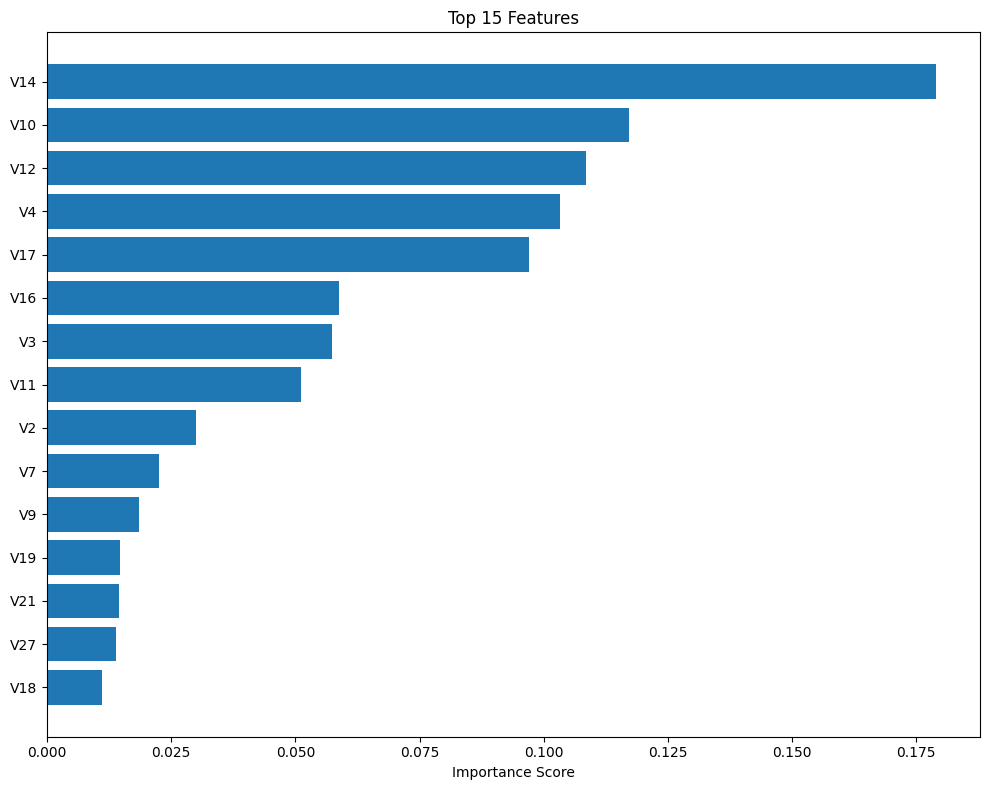

In [27]:
# Create a new figure for displaying feature importance
# figsize=(10, 8) sets the width and height of the chart
plt.figure(figsize=(10, 8))

# Set how many top important features we want to display
top_n = 15

# Select the first 15 most important features
# .head(top_n) returns the top rows from the sorted feature importance DataFrame
top_features = feature_importance.head(top_n)

# Create a horizontal bar chart for the feature importance scores
# range(top_n) gives the bar positions from 0 to 14
plt.barh(range(top_n), top_features['Importance'])

# Replace the Y-axis numbers with the actual feature names
plt.yticks(range(top_n), top_features['Feature'])

# Add a label to the X-axis
# The X-axis shows how important each feature is to the model
plt.xlabel('Importance Score')

# Add a title to the chart
# f-string inserts the value of top_n into the title
plt.title(f'Top {top_n} Features')

# Reverse the Y-axis so the most important feature appears at the top
# plt.gca() gets the current chart area
plt.gca().invert_yaxis()

# Adjust the spacing so labels and chart elements do not overlap
plt.tight_layout()

# Display the feature importance chart
plt.show()

<h1>PHASE 8: LIME EXPLANATIONS</h1>

<h2>STEP 8.1: INITIALIZE LIME EXPLAINER</h2>

In [28]:
# Create a LIME explainer for understanding individual model predictions
explainer = lime.lime_tabular.LimeTabularExplainer(

    # Use the scaled training data as the background data for LIME
    # .values converts the pandas DataFrame into a NumPy array
    X_train_scaled.values,

    # Provide the original feature names so LIME can show readable explanations
    # .tolist() converts the column names into a normal Python list
    feature_names=X.columns.tolist(),

    # Give readable names to the two target classes
    # Class 0 = Legitimate transaction and Class 1 = Fraud transaction
    class_names=['Legitimate', 'Fraud'],

    # Tell LIME that this is a classification problem
    # classification means the model predicts categories such as Legitimate or Fraud
    mode='classification'
)

<h2>STEP 8.2: EXPLAIN FRAUDULENT TRANSACTIONS</h2>

In [34]:
# Reset y_test index so row positions start from 0, 1, 2, ...
y_test_reset = y_test.reset_index(drop=True)

# Find positions of all fraud transactions
fraud_positions = np.where(y_test_reset.values == 1)[0]

# Display how many fraud transactions are present in the test set
print("Number of fraud transactions:", len(fraud_positions))

# Explain the first 3 fraud transactions
for i in range(3):

    # Get the row position of the fraud transaction
    pos = fraud_positions[i]

    # Select the fraud transaction from X_test_scaled
    # .iloc is used because X_test_scaled is a pandas DataFrame
    fraud_instance = X_test_scaled.iloc[pos].values

    # Ask LIME to explain why the model made this prediction
    explanation = explainer.explain_instance(
        fraud_instance,
        best_model.predict_proba,
        num_features=10
    )

    # Calculate the predicted probability that this transaction is fraud
    pred_fraud_prob = best_model.predict_proba(
        fraud_instance.reshape(1, -1)
    )[0, 1]

    # Display transaction information
    print("\n" + "=" * 60)
    print(f"Fraud Transaction {i + 1}")
    print("=" * 60)

    print(f"Row Position: {pos}")
    print(f"Fraud Probability: {pred_fraud_prob:.2%}")

    print("\nTop Contributing Features:")

    # Display the top 5 features influencing the prediction
    for feature, weight in explanation.as_list()[:5]:
        print(f"  {feature}: {weight:.4f}")

Number of fraud transactions: 95

Fraud Transaction 1
Row Position: 845
Fraud Probability: 90.48%
Top Contributing Features:
  V4 > 0.52: 0.0056
  V14 <= -0.45: 0.0050
  V12 <= -0.41: 0.0046
  V17 <= -0.57: 0.0046
  V11 > 0.73: 0.0039

Fraud Transaction 2
Row Position: 1339
Fraud Probability: 82.46%
Top Contributing Features:
  V4 > 0.52: 0.0056
  V14 <= -0.45: 0.0055
  V12 <= -0.41: 0.0049
  V17 <= -0.57: 0.0047
  V3 <= -0.59: 0.0036

Fraud Transaction 3
Row Position: 1784
Fraud Probability: 12.47%
Top Contributing Features:
  V14 <= -0.45: 0.0044
  V4 > 0.52: 0.0041
  V12 <= -0.41: 0.0041
  V3 <= -0.59: 0.0023
  V1 > 0.67: 0.0011


<h2>STEP 8.3: EXPLAIN LEGITIMATE TRANSACTIONS</h2>

In [ ]:
# Reset y_test index

# Reset the index of y_test so row positions start from 0, 1, 2, 3, ...
# drop=True removes the old index instead of keeping it as a new column
y_test_reset = y_test.reset_index(drop=True)

# Get positions of legitimate transactions

# Find the positions where the target value is 0, meaning legitimate transaction
# np.where() returns the positions that match the condition
# [0] takes the array containing those positions
legit_positions = np.where(y_test_reset.values == 0)[0]

# Display the total number of legitimate transactions in the test data
# len() counts how many positions are stored
print("Number of legitimate transactions:", len(legit_positions))

# Explain 3 legitimate transactions

# Repeat the following steps 3 times
for i in range(3):

    # Select a legitimate transaction position
    # i * 1000 picks transactions farther apart instead of taking 3 nearby rows
    pos = legit_positions[i * 1000]

    # Correct NumPy indexing
    # Select the legitimate transaction at the chosen row position
    legit_instance = X_test_scaled[pos]

    # Generate a LIME explanation for this legitimate transaction
    # explain_instance() shows which features influenced the model's prediction
    explanation = explainer.explain_instance(
        legit_instance,                 # Transaction that we want to explain
        best_model.predict_proba,       # Model function used to predict probabilities
        num_features=10                 # Use the top 10 contributing features
    )

    # Predict the fraud probability for this legitimate transaction
    # reshape(1, -1) changes one row into the 2D format expected by the model
    pred_fraud_prob = best_model.predict_proba(
        legit_instance.reshape(1, -1)
    )[0, 1]                             # Select the probability of Class 1 = Fraud

    # Print a separator line before each transaction explanation
    print("\n" + "=" * 60)

    # Display the legitimate transaction number
    # i + 1 starts numbering from 1 instead of 0
    print(f"Legitimate Transaction {i + 1}")

    # Print another separator line
    print("=" * 60)

    # Display the row position of the selected transaction
    print(f"Row Position: {pos}")

    # Display the model's predicted fraud probability as a percentage
    # :.2% shows the value as a percentage with 2 decimal places
    print(f"Fraud Probability: {pred_fraud_prob:.2%}")

    # Print a heading before showing the important features
    print("\nTop Contributing Features:")

    # Get the first 5 most important feature explanations from LIME
    # feature contains the feature condition and weight shows its contribution
    for feature, weight in explanation.as_list()[:5]:

        # Display each feature and its LIME contribution value
        # Positive weights support fraud prediction; negative weights support legitimate prediction
        print(f"{feature}: {weight:.4f}")

<h1>PHASE 9: SUMMARY AND CONCLUSIONS</h1>

<h2>STEP 9.1: GENERATE SUMMARY REPORT</h2>

In [35]:
print("=" * 80)
print("FRAUD DETECTION PROJECT - SUMMARY REPORT")
print("=" * 80)

# Display the total number of transactions in the dataset
# len(df) gives the total number of rows
# :, adds commas to large numbers for easier reading
print("\n1. PROBLEM CONTEXT")
print(f"   - Total transactions: {len(df):,}")

# Display the total number and percentage of fraud transactions
# y == 1 checks fraud cases and .sum() counts them
# Dividing by len(y) and multiplying by 100 gives the fraud percentage
print(f"   - Frauds: {(y==1).sum():,} ({(y==1).sum()/len(y)*100:.2f}%)")

# Display the total number and percentage of legitimate transactions
# y == 0 checks legitimate cases and .sum() counts them
print(f"   - Legitimate: {(y==0).sum():,} ({(y==0).sum()/len(y)*100:.2f}%)")

# Display the class imbalance ratio
# 577:1 means there are about 577 legitimate transactions for every 1 fraud transaction
print(f"   - Class imbalance ratio: 577:1")

# Find the row containing the model with the highest F1-score
# .idxmax() finds the index of the highest F1-score
# .loc[] selects the complete row using that index
print("\n2. BEST MODEL PERFORMANCE")
best_score = comparison_df.loc[comparison_df['F1-Score'].idxmax()]

# Display the name of the best model
print(f"   - Model: {best_score['Model']}")

# Display the precision score of the best model
# Higher precision usually means fewer legitimate transactions are wrongly flagged as fraud
print(f"   - Precision: {best_score['Precision']:.4f} (low false alarm rate)")

# Display the recall score of the best model
# Higher recall means the model detects more actual fraud transactions
print(f"   - Recall: {best_score['Recall']:.4f} (high fraud detection)")

# Display the F1-score of the best model
# F1-score gives a balance between precision and recall
print(f"   - F1-Score: {best_score['F1-Score']:.4f}")

# Display the ROC-AUC score of the best model
# ROC-AUC shows how well the model separates fraud and legitimate transactions
print(f"   - ROC-AUC: {best_score['ROC-AUC']:.4f}")

# Loop through the top 5 most important features
# .head(5) selects the first 5 rows
# .iterrows() gives the row index and row data one at a time
print("\n3. TOP FRAUD INDICATORS")
for idx, row in feature_importance.head(5).iterrows():

    # Display the feature name and its importance score
    # :.4f shows the importance value up to 4 decimal places
    print(f"   - {row['Feature']}: {row['Importance']:.4f}")

# Print the heading for deployment recommendations
print("\n4. DEPLOYMENT RECOMMENDATIONS")

# Recommend using 0.5 as the basic fraud probability threshold
print("   - Set fraud threshold at 0.5 probability")

# Recommend sending transactions with probability above 0.7 for automatic review
print("   - Flag transactions >0.7 for automatic review")

# Recommend checking model performance every month
print("   - Monitor model performance monthly")

# Recommend retraining the model every quarter using newer fraud patterns
print("   - Retrain quarterly with new fraud patterns")

print("\n" + "=" * 80)

FRAUD DETECTION PROJECT - SUMMARY REPORT

1. PROBLEM CONTEXT
   - Total transactions: 283,726
   - Frauds: 473 (0.17%)
   - Legitimate: 283,253 (99.83%)
   - Class imbalance ratio: 577:1

2. BEST MODEL PERFORMANCE
   - Model: Random Forest
   - Precision: 0.9324 (low false alarm rate)
   - Recall: 0.7263 (high fraud detection)
   - F1-Score: 0.8166
   - ROC-AUC: 0.9424

3. TOP FRAUD INDICATORS
   - V14: 0.1789
   - V10: 0.1171
   - V12: 0.1085
   - V4: 0.1032
   - V17: 0.0971

4. DEPLOYMENT RECOMMENDATIONS
   - Set fraud threshold at 0.5 probability
   - Flag transactions >0.7 for automatic review
   - Monitor model performance monthly
   - Retrain quarterly with new fraud patterns

